In [1]:
"""
Этап 9 (бонус). RFM-анализ клиентов.

Что считаем:
- R (Recency): сколько дней с последней покупки.
- F (Frequency): сколько заказов.
- M (Monetary): сколько денег принёс клиент.
Сегментируем клиентов и сохраняем в Postgres.
"""
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))

from scripts.db_config import read_sql, execute_sql, _get_conn_params

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

REPORTS_DIR = ROOT_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

print("✅ Окружение готово")

✅ Окружение готово


In [2]:
# Analysis date — 1 день после последней продажи в данных
analysis_date = read_sql("""
    SELECT MAX(invoice_date) + INTERVAL '1 day' AS analysis_date
    FROM sales;
""")
analysis_date = pd.to_datetime(analysis_date["analysis_date"].iloc[0])
print(f"Дата анализа: {analysis_date.date()}")

# RFM по клиентам
rfm = read_sql("""
    SELECT
        customer_id,
        MAX(invoice_date)                    AS last_purchase,
        COUNT(DISTINCT invoice_no)           AS frequency,
        ROUND(SUM(revenue)::numeric, 2)      AS monetary
    FROM sales
    WHERE customer_id IS NOT NULL
    GROUP BY customer_id;
""")

rfm["last_purchase"] = pd.to_datetime(rfm["last_purchase"])
rfm["recency"] = (analysis_date - rfm["last_purchase"]).dt.days
rfm["monetary"] = rfm["monetary"].astype(float)
rfm["customer_id"] = rfm["customer_id"].astype(int)

print(f"Всего клиентов: {len(rfm):,}")
print(f"Средний R: {rfm['recency'].mean():.0f} дней")
print(f"Средний F: {rfm['frequency'].mean():.1f} заказов")
print(f"Средний M: £{rfm['monetary'].mean():,.2f}")

display(rfm.describe(percentiles=[0.25, 0.5, 0.75]).round(2))

Дата анализа: 2011-12-10
Всего клиентов: 5,852
Средний R: 200 дней
Средний F: 6.3 заказов
Средний M: £2,979.05


,customer_id,last_purchase,frequency,monetary,recency
count,"5,852.00",5852,"5,852.00","5,852.00","5,852.00"
mean,"15,319.71",2011-05-23 19:33:08.971291904,6.25,"2,979.05",200.20
min,"12,346.00",2009-12-01 10:49:00,1.00,2.95,1.00
25%,"13,837.75",2010-11-25 16:23:45,1.00,344.89,25.00
50%,"15,320.50",2011-09-05 15:19:30,3.00,880.38,95.00
75%,"16,802.25",2011-11-14 12:55:15,7.00,"2,289.34",379.00
max,"18,287.00",2011-12-09 12:50:00,373.00,"608,821.65",739.00
std,"1,714.93",NaN,12.75,"14,605.12",208.51


In [3]:
# Разбиваем на квинтили (1-5)
# R: обратная шкала — меньше дней = лучше
rfm["r_score"] = pd.qcut(
    rfm["recency"], q=5, labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["f_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=5, labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["m_score"] = pd.qcut(
    rfm["monetary"], q=5, labels=[1, 2, 3, 4, 5]
).astype(int)

# Объединённый RFM-скор
rfm["rfm_score"] = (
    rfm["r_score"].astype(str) +
    rfm["f_score"].astype(str) +
    rfm["m_score"].astype(str)
)

# Общая сумма баллов
rfm["rfm_total"] = rfm["r_score"] + rfm["f_score"] + rfm["m_score"]

print("Распределение по баллам:")
display(rfm[["r_score", "f_score", "m_score"]].describe().round(2))

print("\nТоп-10 клиентов:")
display(rfm.nlargest(10, "rfm_total")[[
    "customer_id", "recency", "frequency", "monetary",
    "r_score", "f_score", "m_score", "rfm_total",
]])

Распределение по баллам:


,r_score,f_score,m_score
count,"5,852.00","5,852.00","5,852.00"
mean,3.01,3.00,3.00
std,1.42,1.41,1.41
min,1.00,1.00,1.00
25%,2.00,2.00,2.00
50%,3.00,3.00,3.00
75%,4.00,4.00,4.00
max,5.00,5.00,5.00



Топ-10 клиентов:


,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_total
16,12362,3,10,"4,737.23",5,5,5,15
48,12395,19,15,"4,551.27",5,5,5,15
69,12417,3,20,"6,017.91",5,5,5,15
85,12433,1,10,"20,581.26",5,5,5,15
89,12437,2,38,"11,282.40",5,5,5,15
122,12471,2,71,"35,145.50",5,5,5,15
125,12474,17,29,"11,362.45",5,5,5,15
127,12476,16,18,"12,351.41",5,5,5,15
134,12483,17,19,"4,092.58",5,5,5,15
141,12490,5,20,"8,764.64",5,5,5,15


In [4]:
def assign_segment(row):
    """Назначить RFM-сегмент."""
    r, f, m = row["r_score"], row["f_score"], row["m_score"]

    # Champions: недавно, часто, много
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    # Loyal: недавно и часто
    if r >= 3 and f >= 3:
        return "Loyal Customers"
    # Potential Loyalist: недавно, но редко
    if r >= 4 and f <= 2:
        return "New Customers"
    # At Risk: давно, но раньше были активны
    if r <= 2 and f >= 3:
        return "At Risk"
    # Can't Lose Them: очень давно, были активны
    if r == 1 and f >= 4 and m >= 4:
        return "Can't Lose Them"
    # Hibernating / Lost
    if r <= 2 and f <= 2:
        return "Lost"
    return "Others"

rfm["segment"] = rfm.apply(assign_segment, axis=1)

# Сводка по сегментам
segment_summary = (
    rfm.groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        total_revenue=("monetary", "sum"),
    )
    .sort_values("customers", ascending=False)
)

segment_summary["pct_customers"] = (
    segment_summary["customers"] / len(rfm) * 100
)
segment_summary["pct_revenue"] = (
    segment_summary["total_revenue"] / rfm["monetary"].sum() * 100
)

print("Сводка по RFM-сегментам:")
display(segment_summary.round(2))

Сводка по RFM-сегментам:


,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,pct_customers,pct_revenue
segment,,,,,,,
Lost,1508,456.93,1.25,419.79,"633,039.22",25.77,3.63
Loyal Customers,1389,71.04,5.36,"1,888.25","2,622,785.36",23.74,15.04
Champions,1294,19.95,16.98,"9,210.08","11,917,844.14",22.11,68.36
At Risk,828,368.02,4.98,"1,978.40","1,638,113.74",14.15,9.40
New Customers,452,28.08,1.46,927.81,"419,370.58",7.72,2.41
Others,381,106.59,1.36,530.79,"202,232.69",6.51,1.16


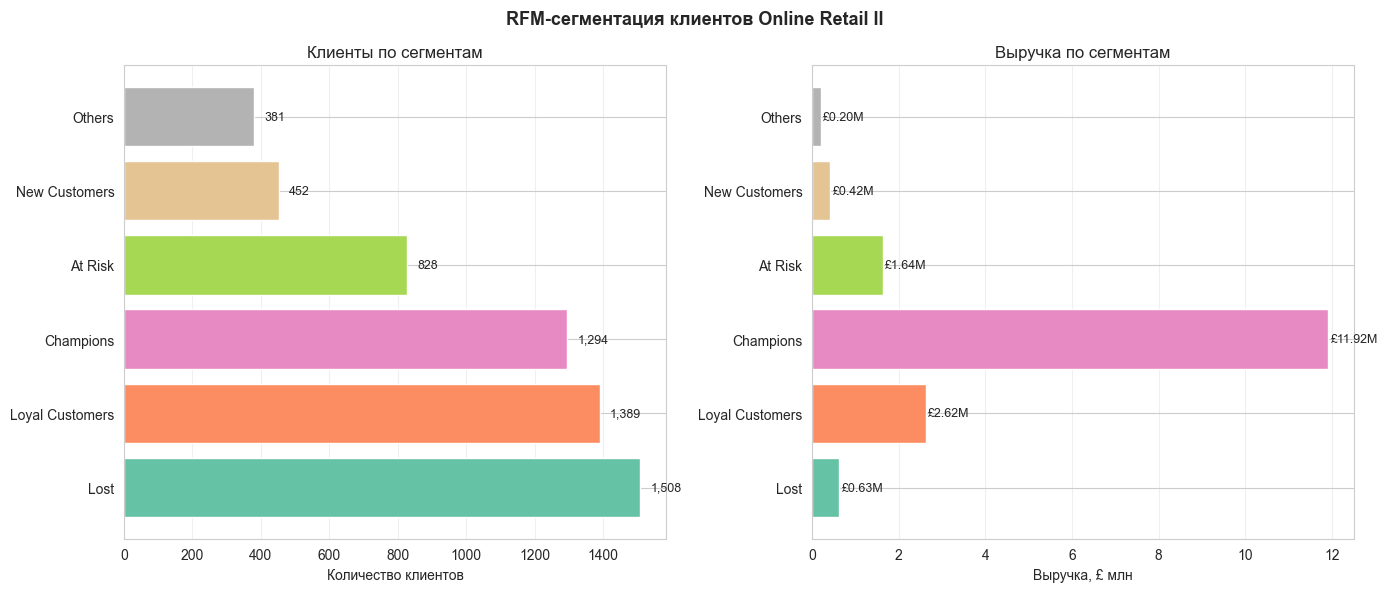

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Клиенты по сегментам
seg_order = segment_summary.index
colors = plt.cm.Set2(np.linspace(0, 1, len(seg_order)))

axes[0].barh(seg_order, segment_summary["customers"], color=colors)
axes[0].set_xlabel("Количество клиентов")
axes[0].set_title("Клиенты по сегментам")
axes[0].grid(alpha=0.3, axis="x")

for i, v in enumerate(segment_summary["customers"]):
    axes[0].text(v + 30, i, f"{v:,}", va="center", fontsize=9)

# Выручка по сегментам
axes[1].barh(seg_order, segment_summary["total_revenue"] / 1e6, color=colors)
axes[1].set_xlabel("Выручка, £ млн")
axes[1].set_title("Выручка по сегментам")
axes[1].grid(alpha=0.3, axis="x")

for i, v in enumerate(segment_summary["total_revenue"] / 1e6):
    axes[1].text(v + 0.05, i, f"£{v:.2f}M", va="center", fontsize=9)

plt.suptitle("RFM-сегментация клиентов Online Retail II", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "rfm_segments.png", dpi=120, bbox_inches="tight")
plt.show()

In [7]:
rfm_for_db = rfm[[
    "customer_id", "recency", "frequency", "monetary",
    "r_score", "f_score", "m_score", "rfm_score", "segment",
]].copy()

execute_sql("DROP TABLE IF EXISTS rfm;")
execute_sql("""
    CREATE TABLE rfm (
        customer_id  integer PRIMARY KEY,
        recency      integer,
        frequency    integer,
        monetary     numeric,
        r_score      integer,
        f_score      integer,
        m_score      integer,
        rfm_score    text,
        segment      text
    );
""")

insert_sql = "INSERT INTO rfm VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s);"
rows = [tuple(r) for r in rfm_for_db.itertuples(index=False, name=None)]

with psycopg2.connect(**_get_conn_params()) as conn:
    with conn.cursor() as cur:
        cur.executemany(insert_sql, rows)
    conn.commit()

print(f"✅ Таблица rfm сохранена ({len(rows):,} строк)")

# Проверка
display(read_sql("""
    SELECT segment, COUNT(*) AS n
    FROM rfm
    GROUP BY segment
    ORDER BY n DESC;
"""))

✅ Таблица rfm сохранена (5,852 строк)


,segment,n
0,Lost,1508
1,Loyal Customers,1389
2,Champions,1294
3,At Risk,828
4,New Customers,452
5,Others,381


## Этап 9 (бонус). RFM-сегментация клиентов — ВЫВОДЫ

### Методология
- **R (Recency):** дней с последней покупки. Меньше = лучше.
- **F (Frequency):** количество заказов.
- **M (Monetary):** общая выручка от клиента.
- Каждый параметр разбит на **5 квинтилей** (1-5).
- Дата анализа: **2011-12-10**.

### Итоги сегментации

| Сегмент | Клиентов | % | Выручка | % выручки | Средний чек |
|---------|----------|---|---------|-----------|-------------|
| **Champions** | 1 294 | 22.11% | £11 917 844 | **68.36%** | £9 210 |
| **Loyal Customers** | 1 389 | 23.74% | £2 622 785 | 15.04% | £1 888 |
| **At Risk** | 828 | 14.15% | £1 638 114 | 9.40% | £1 978 |
| **Lost** | 1 508 | **25.77%** | £633 039 | 3.63% | £420 |
| New Customers | 452 | 7.72% | £419 371 | 2.41% | £928 |
| Others | 381 | 6.51% | £202 233 | 1.16% | £531 |
| **Всего** | **5 852** | 100% | £17 433 386 | 100% | £2 979 |

⚠️ **RFM покрывает 87% выручки** — 23% продаж без customer_id
не входят в сегментацию.

### Ключевые выводы

1. **Парето подтверждается на клиентах:** топ 46% клиентов
   (Champions + Loyal) дают **83.4% выручки**.

2. **Champions — 22% клиентов, 68% выручки.**
   Это ядро бизнеса. Средний чек £9 210 — оптовики.
   **Стратегия:** VIP-программа, персональный менеджер, ранний доступ.

3. **At Risk — критичная зона.** 828 клиентов, £1.6M выручки.
   Средний чек **£1 978 — ВЫШЕ, чем у Loyal** (£1 888).
   Они раньше были активны, но уходят (368 дней без покупки).
   **Потеря этой группы — £1.6M.** Реактивация дешевле удержания.
   **Стратегия:** персональные реактивационные кампании со скидкой.

4. **Lost — 26% клиентов, 3.6% выручки.** Давно не покупали
   (456 дней), средний чек £420.
   **Стратегия:** дешёвые массовые рассылки, не тратить много ресурсов.

5. **Сравнение Champions vs Lost:**
   - Почти равное количество (1 294 vs 1 508).
   - Champions приносят **в 19 раз больше выручки**.
   - Средний чек в **22 раза выше**.
   - **Вывод:** удержать 1 Champions = вернуть 19 Lost.

6. **New Customers — 8% клиентов.** Недавно пришли, но мало заказов.
   Критичен **второй заказ** — это переломный момент retention.
   **Стратегия:** welcome-серия, обучение, бонус за 2-й заказ.

### Рекомендации для маркетинга

| Сегмент | Приоритет | Действие |
|---------|-----------|----------|
| **Champions** | Критический | VIP-программа, персональный контакт |
| **At Risk** | **Высокий** | Реактивация: скидка + персональное письмо |
| **Loyal** | Средний | Upsell, скидки на объём |
| **New** | Средний | Welcome-серия, бонус за 2-й заказ |
| **Lost** | Низкий | Массовая дешёвая рассылка |
| **Others** | Низкий | Общая коммуникация |

### Ограничения
- **23% выручки без customer_id** — не покрываются RFM.
- **Дата анализа фиксирована** (2011-12-10). Для регулярной работы — скользящая.
- **RFM смотрит в прошлое.** Не учитывает переход клиента к конкурентам.
- **Квинтили (5 групп)** — стандарт. Для больших данных лучше децили.

### Графики
- `reports/rfm_segments.png` — сегменты по клиентам и выручке.

### Что дальше
**Этап 10 (бонус, опционально):** BCG-матрица по годам.
**Этап 11 (бонус, опционально):** Basket analysis.
**Superset:** дашборд с RFM + ABC/XYZ.